# Phase 7: Deep Visual EDA & SHAP Analysis

In this notebook, we will:
1. Plot **KDE Distributions** to find features where the classes completely overlap (noise).
2. Plot **Bivariate Relationships** to find bias.
3. Use **SHAP (SHapley Additive exPlanations)** to prove which features are driving the predictions.

In [2]:
# !pip install shap seaborn matplotlib fastparquet --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb
import shap
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid", palette="pastel")

/Users/USER/Desktop/zindi/ml_env/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
train_df = pd.read_parquet('../data/features/train_features.parquet', engine='fastparquet')
raw_train = pd.read_csv('../data/Train.csv')

target = raw_train['liquidity_stress_next_30d']
X = train_df.drop(columns=['ID', 'liquidity_stress_next_30d'])

# encode categorical columns for SHAP
cat_cols = X.select_dtypes(include=['object', 'category']).columns
if len(cat_cols) > 0:
    X = pd.get_dummies(X, columns=cat_cols, drop_first=True)
X = X.astype({col: int for col in X.select_dtypes(include=bool).columns})

print(f"Data loaded. Shape: {X.shape}")

Data loaded. Shape: (40000, 228)


## Target-Driven Visual EDA
We will visualize how our new Domain-Informed features separate users who experience liquidity stress vs those who don't using KDE plots

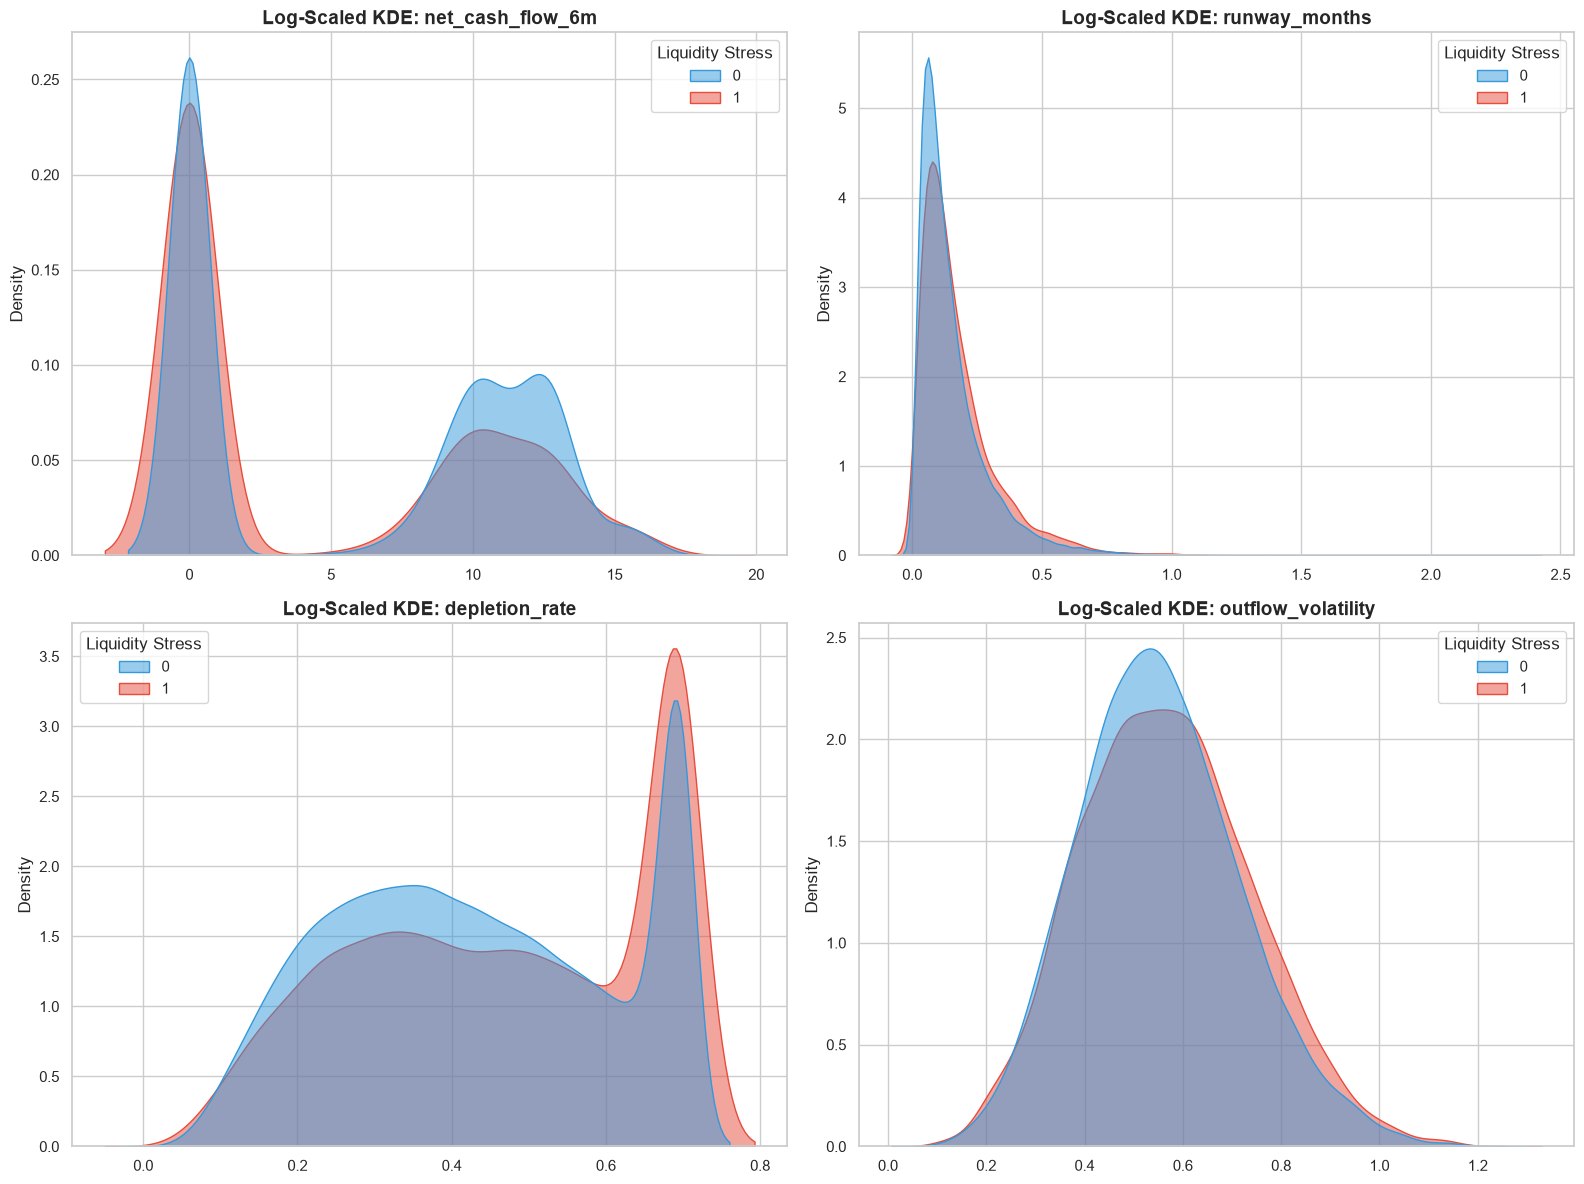

In [4]:
features_to_plot = ['net_cash_flow_6m', 'runway_months', 'depletion_rate', 'outflow_volatility']

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, feature in enumerate(features_to_plot):
    if feature in X.columns:
        # We use a robust scaler (log1p) just for visualization because financial data is highly skewed
        plot_data = pd.DataFrame({
            'Value': np.log1p(X[feature].clip(lower=0)), # Clip negatives for log, just for plotting
            'Liquidity Stress': target
        })
        
        sns.kdeplot(
            data=plot_data, x='Value', hue='Liquidity Stress', 
            fill=True, common_norm=False, ax=axes[i], alpha=0.5, 
            palette={0: "#3498db", 1: "#e74c3c"}
        )
        axes[i].set_title(f'Log-Scaled KDE: {feature}', fontsize=14, fontweight='bold')
        axes[i].set_xlabel('')
        axes[i].set_ylabel('Density')

plt.tight_layout()
plt.show()

## Train SHAP Interpreter Model
here, we train a single LightGBM model using our Optuna Best Parameters.

In [5]:
lgb_params = {
    'learning_rate': 0.07000857701607659, 
    'num_leaves': 27, 
    'max_depth': 8, 
    'min_child_samples': 71, 
    'subsample': 0.7227032899255299, 
    'colsample_bytree': 0.8012769608390673, 
    'n_estimators': 500, 
    'random_state': 42, 
    'verbosity': -1
}

model = lgb.LGBMClassifier(**lgb_params)
model.fit(X, target)
print("Interpreter Model Trained.")

Interpreter Model Trained.


## SHAP Summary Plot

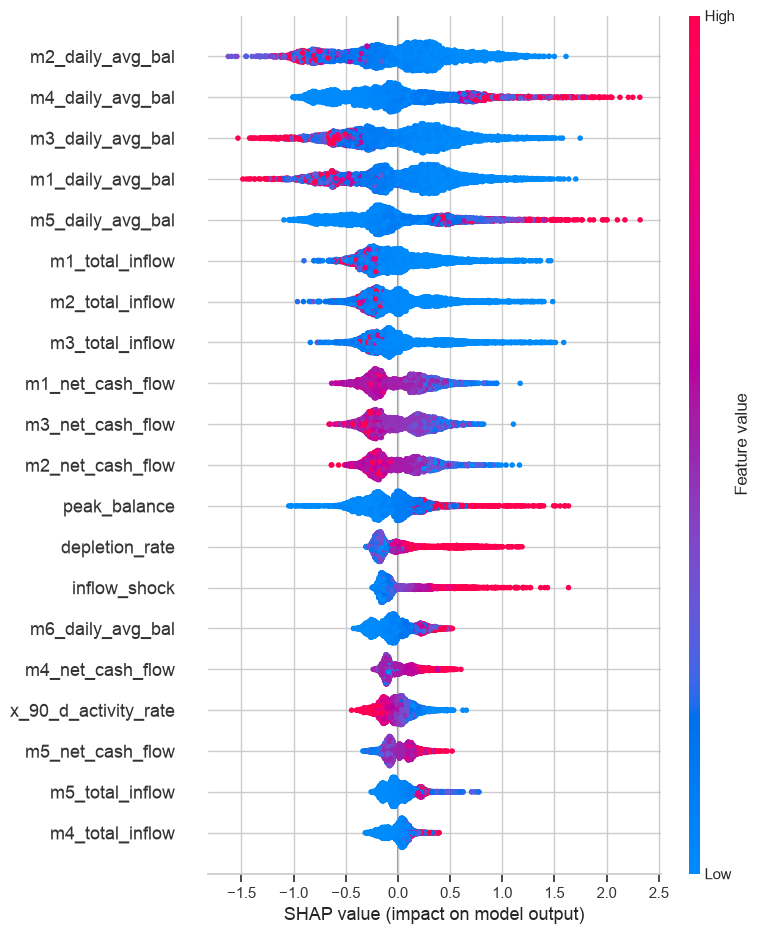

In [6]:
# SHAP can be computationally expensive, so we sample 5000 rows for the explainer
X_sample = X.sample(5000, random_state=42)

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_sample)

plt.figure(figsize=(12, 10))
shap.summary_plot(shap_values, X_sample, max_display=20)

## 5. SHAP Interaction (Bivariate) Plot
Let's look at the interaction between the two most important features.

<Figure size 1000x800 with 0 Axes>

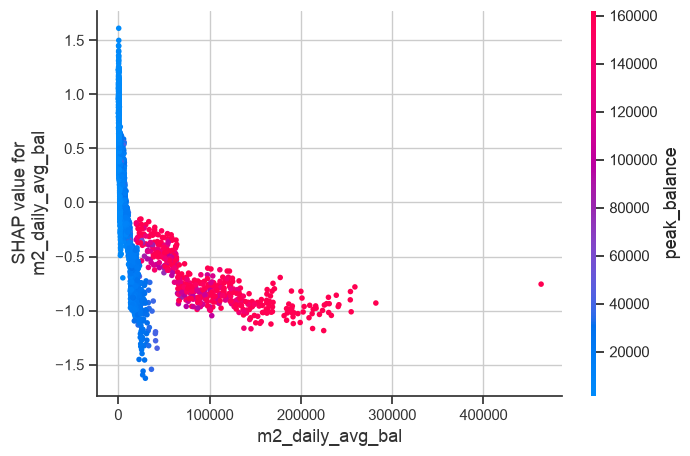

In [7]:
# Get the top feature name dynamically
top_feature = X.columns[np.argsort(np.abs(shap_values).mean(0))[-1]]

plt.figure(figsize=(10, 8))
shap.dependence_plot(top_feature, shap_values, X_sample)
plt.show()